In [2]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import sys, os
import glob
from pathlib import Path

#import astropy
from astropy.table import vstack, Table, QTable, join
from astropy.io import ascii 
from astropy.io import fits
from astropy.convolution import convolve, Box1DKernel
import astropy.units as u
from astropy.coordinates import SkyCoord

import synphot
from synphot import SourceSpectrum
from synphot import units as su
from synphot import SpectralElement
from synphot.observation import Observation

from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

from quasar_unred import load_template, extinguish, fit_composite, find_ebv, mc_spec


In [3]:
w2m_table_file = 'W2M_QSOs.csv'
w2m_table = Table.read(w2m_table_file)

redshift = (w2m_table['zsp'])
src = (w2m_table['src'])
designation = (w2m_table['designation'])
ra = np.array(w2m_table['ra'])
dec = np.array(w2m_table['dec'])

# define the wavelength array for g,r,i,J,H,K,W1,W2,W3,W4
lam = [3542.,4686., 6165., 7481., 8923., 12355., 16458., 21603.] * u.AA

# convert to flambda #(fr/1E-23)*(1/3.34E4)*(1/lam[1])**2
# flam = 10**(-0.4*( mag + 2.406 + 5*np.log10(lam[0]) ))
# use the units module in astropy -- this doesnt really get used anymore...
flam_u = (np.array(w2m_table['umag'])*u.ABmag).to((su.FLAM), u.spectral_density(lam[0]))
flam_g = (np.array(w2m_table['gmag'])*u.ABmag).to((su.FLAM), u.spectral_density(lam[1]))
flam_r = (np.array(w2m_table['rmag'])*u.ABmag).to((su.FLAM), u.spectral_density(lam[2]))
flam_i = (np.array(w2m_table['imag'])*u.ABmag).to((su.FLAM), u.spectral_density(lam[3]))
flam_z = (np.array(w2m_table['zmag'])*u.ABmag).to((su.FLAM), u.spectral_density(lam[4]))
flam_j = (np.array(w2m_table['j_m_2mass'] + 0.894) * u.ABmag).to((su.FLAM), u.spectral_density(lam[5]))
flam_h = (np.array(w2m_table['h_m_2mass'] + 1.374) * u.ABmag).to((su.FLAM), u.spectral_density(lam[6]))
flam_k = (np.array(w2m_table['k_m_2mass'] + 1.840) * u.ABmag).to((su.FLAM), u.spectral_density(lam[7]))

w2m_names = [substring[1:5] + substring[10:15] for substring in designation]
print(w2m_names)

['0813+1004', '0832+0509', '0838+0835', '0840+0355', '0900+0823', '0911+0344', '0911+0950', 'ddJ0.68+0', '0916+0237', '0916+0627', '0920+0413', '0923+0520', '0932+1442', '0933+0705', '0942+0855', '0952+0310', '0957+0211', '1024+0726', '1029+0131', '1044+1350', '1100+0804', '1102+0431', '1146+1054', '1152+0636', '1206+0815', '1219+1215', '1222+1340', '1231+1334', '1243+0800', '1314+0412', '1330+0840', '1334+0631', '1337+1035', '1404+0248', '1406+1611', '1423+1030', '1430+1525', '1434+0935', '1440+0439', '1501+0206', '1509+0851', '1515+0129', '1532+0935', '1553+1004', '1558+0919']


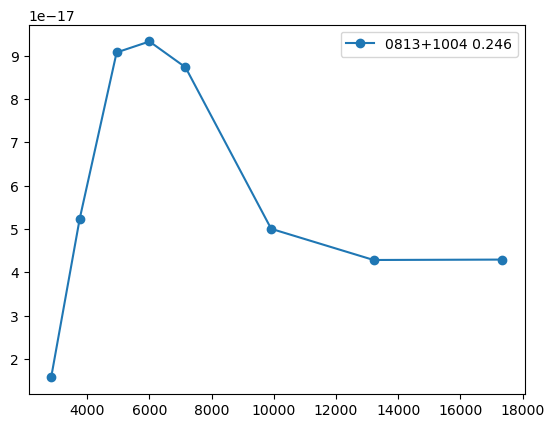

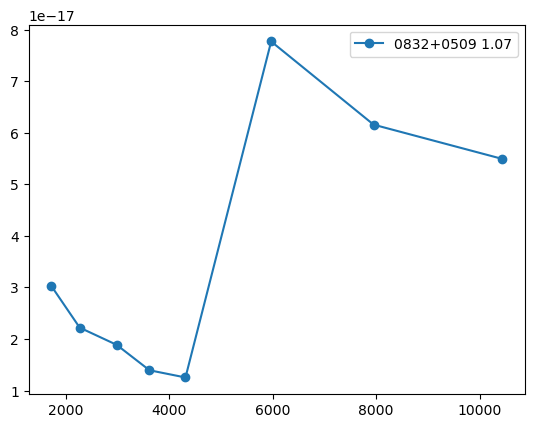

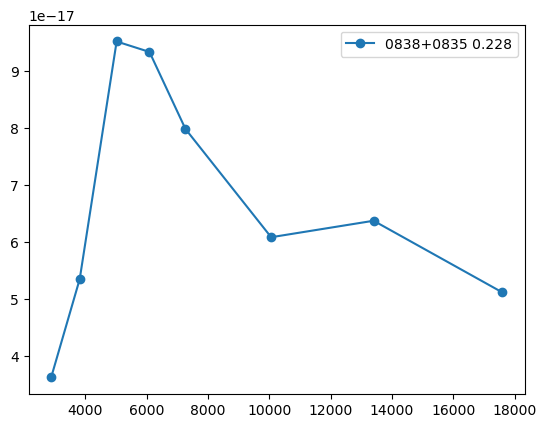

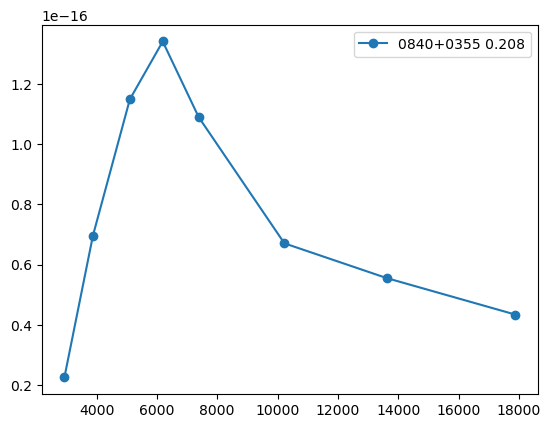

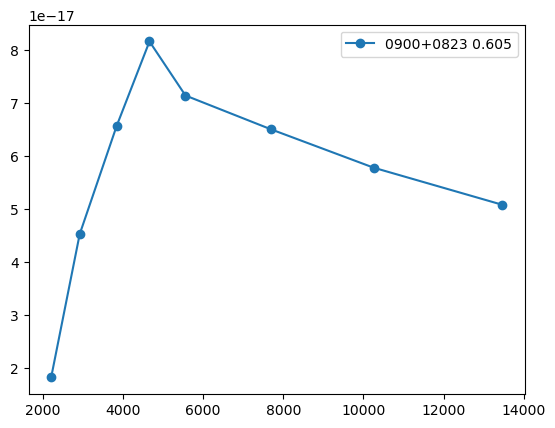

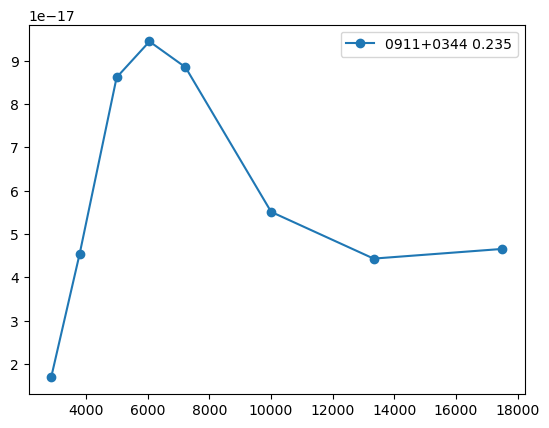

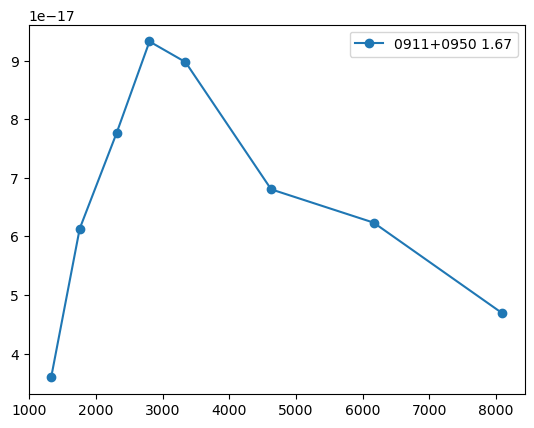

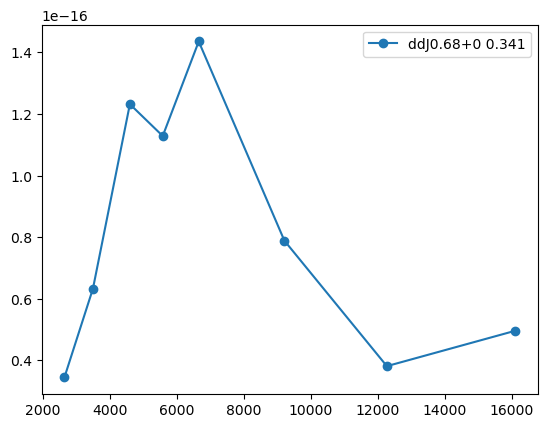

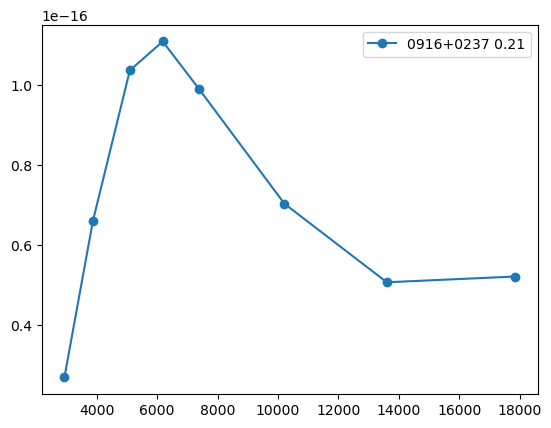

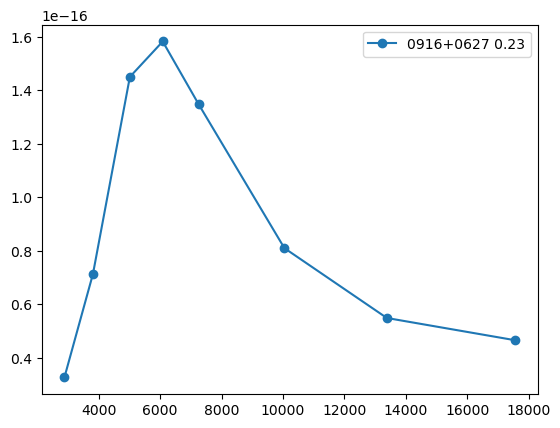

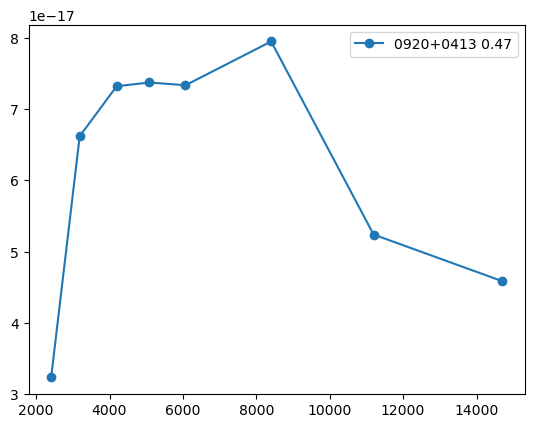

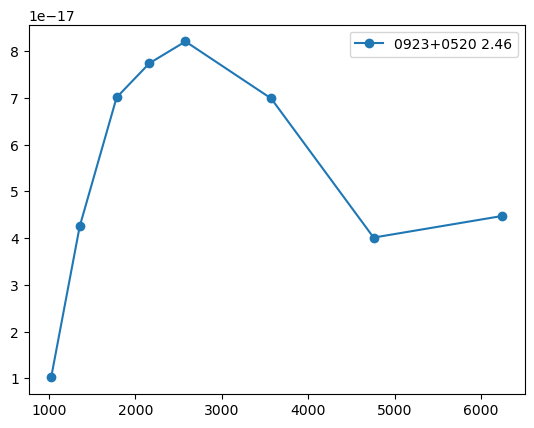

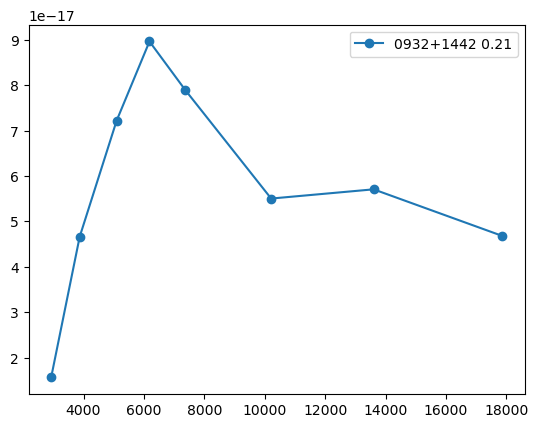

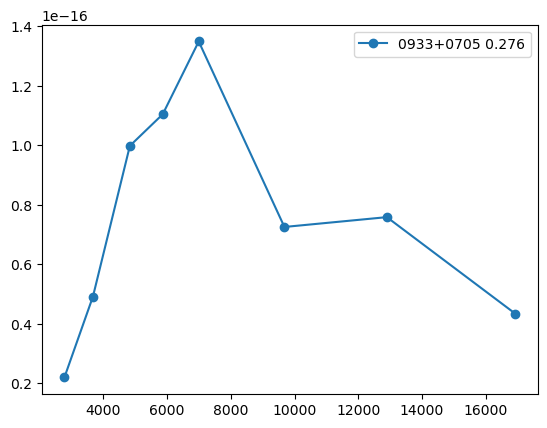

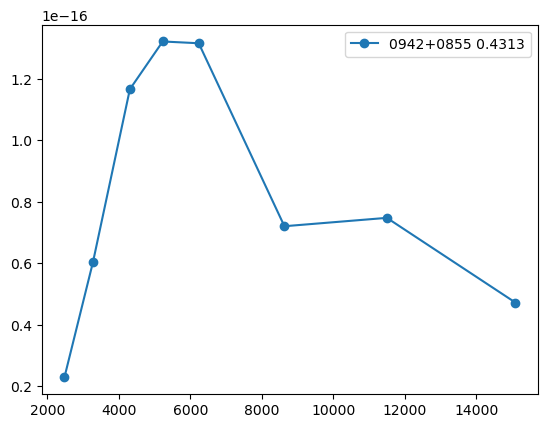

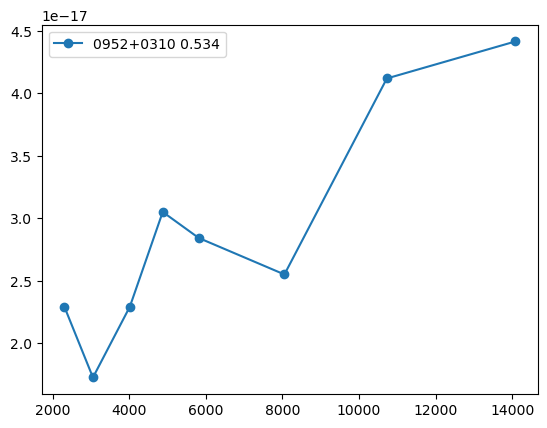

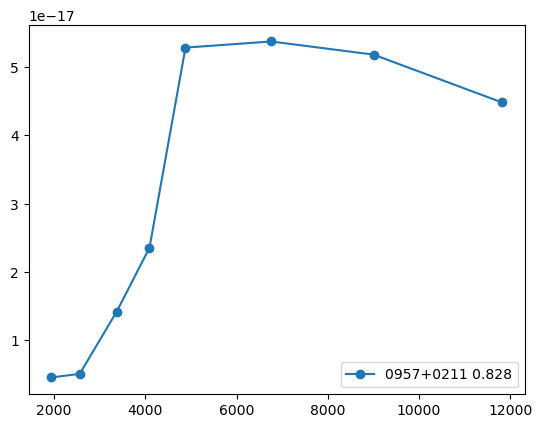

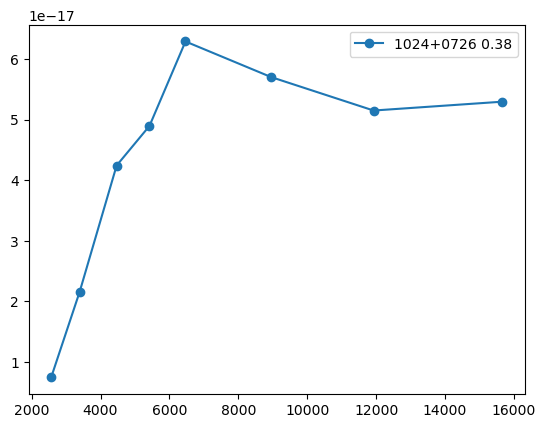

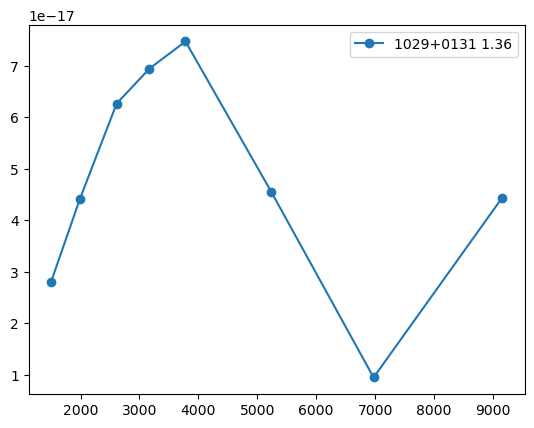

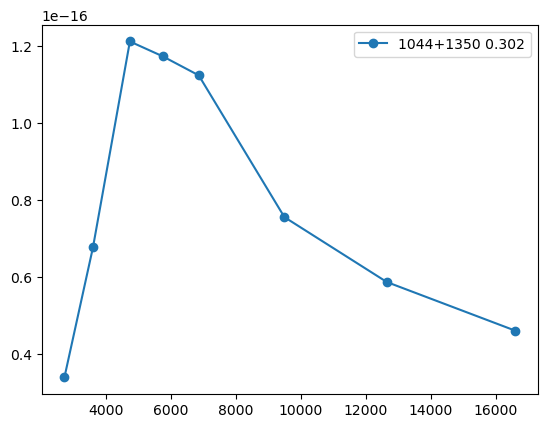

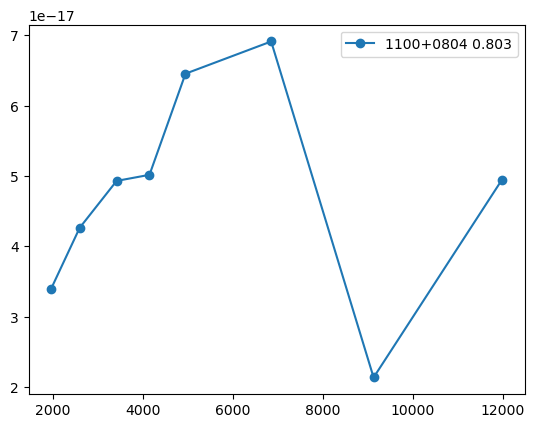

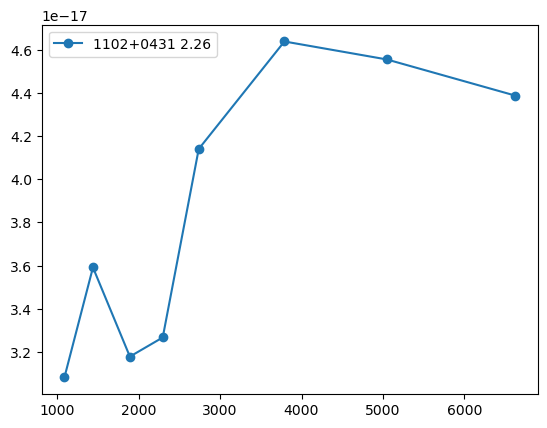

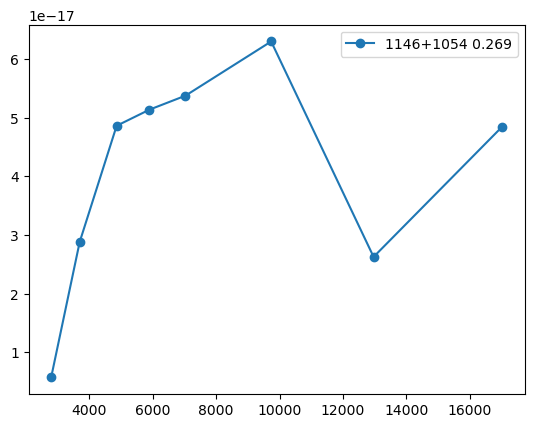

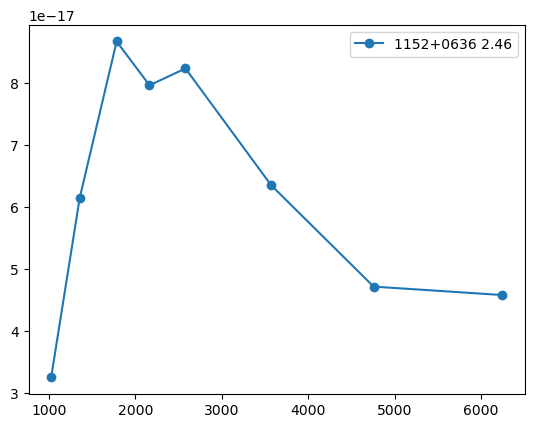

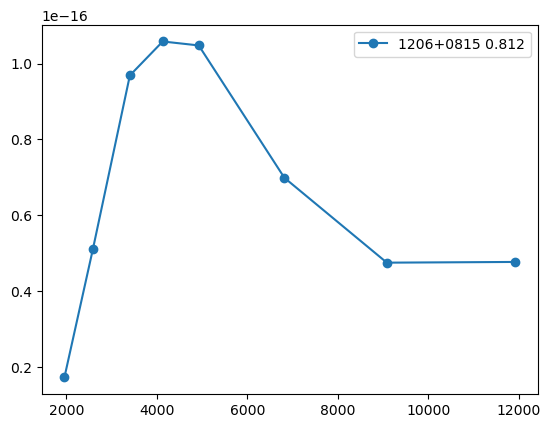

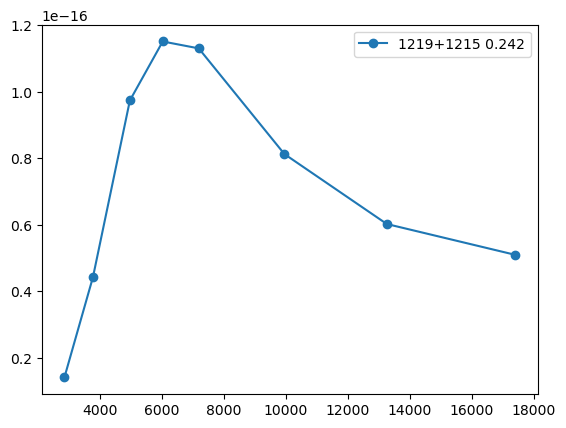

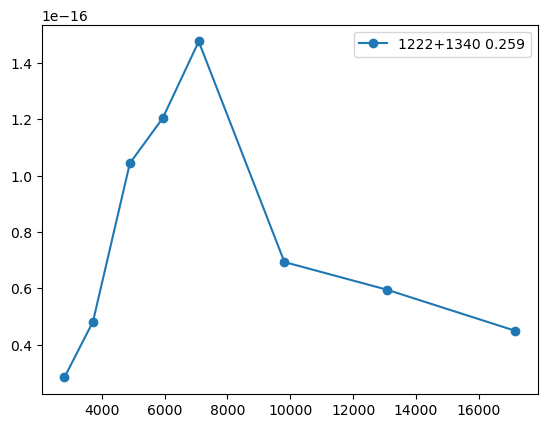

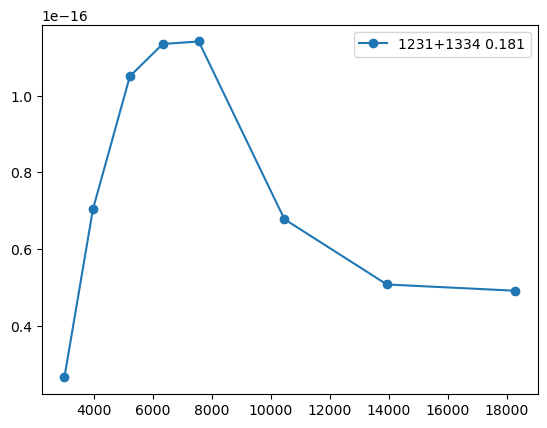

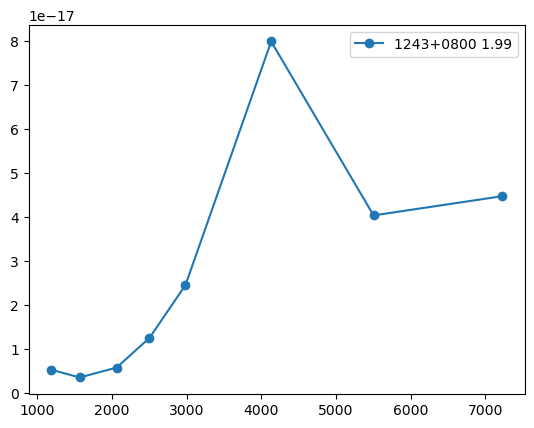

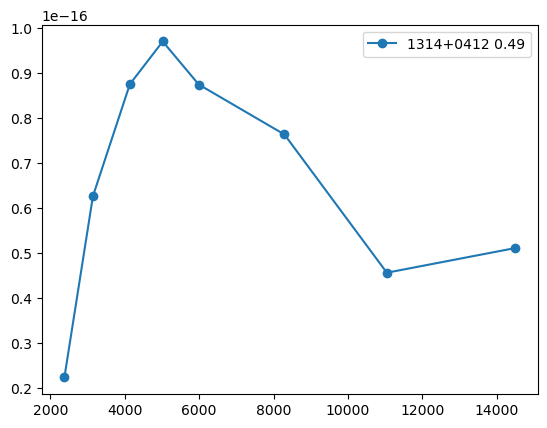

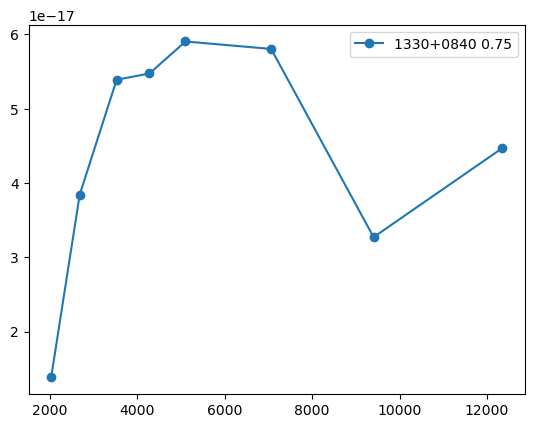

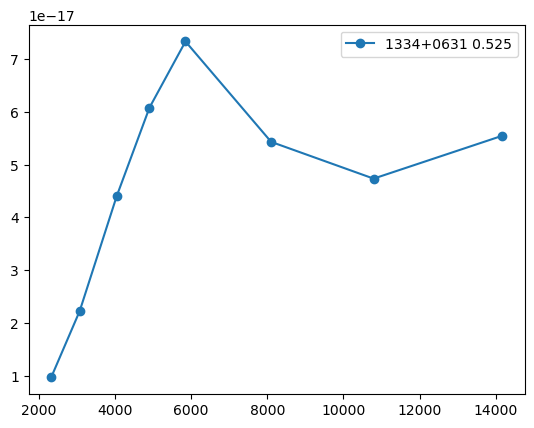

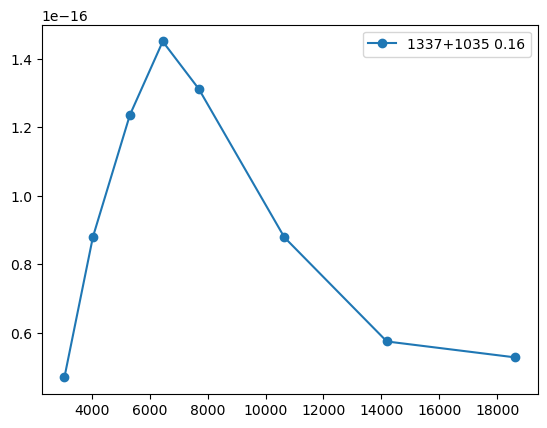

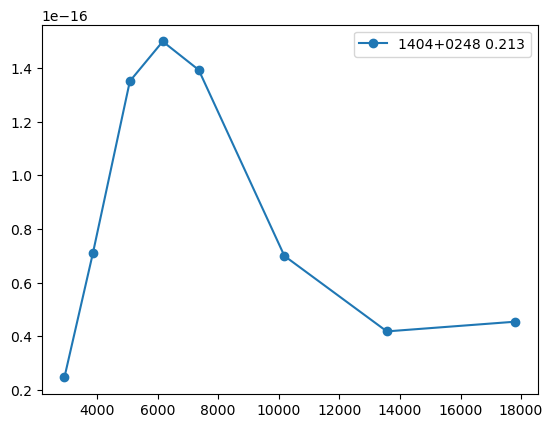

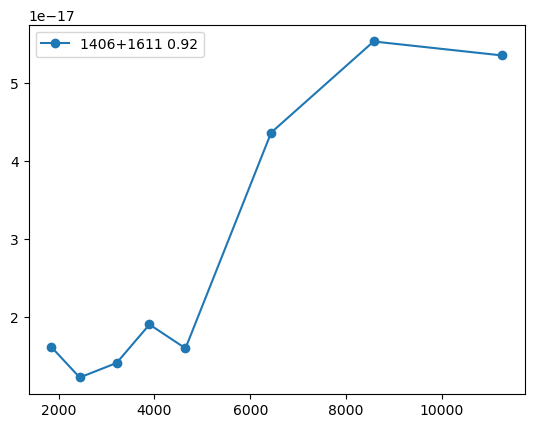

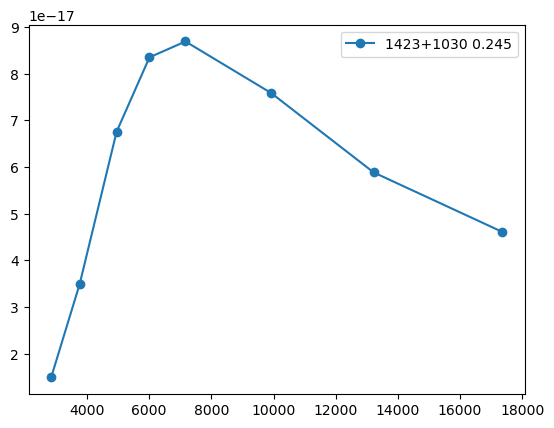

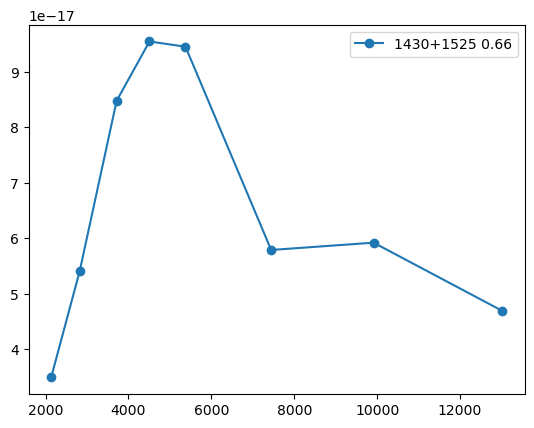

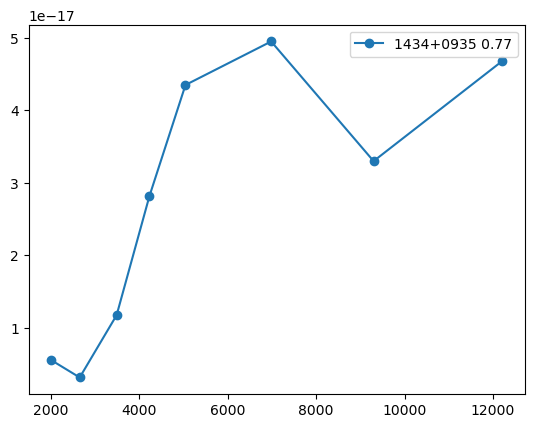

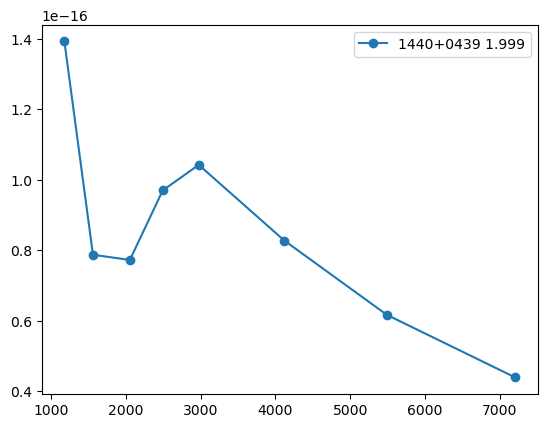

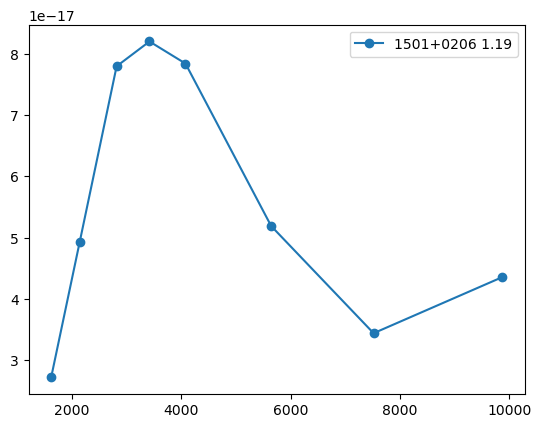

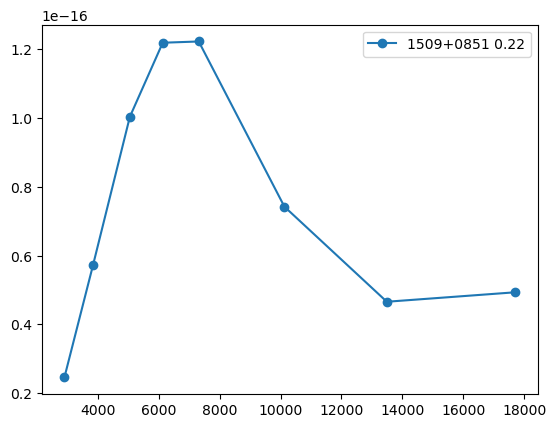

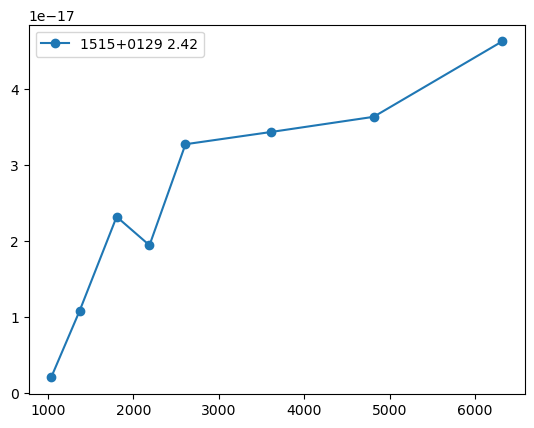

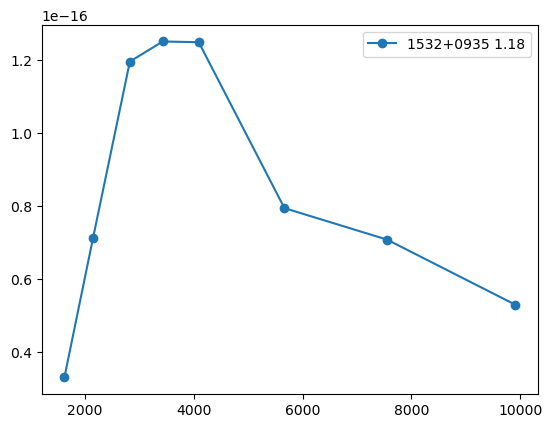

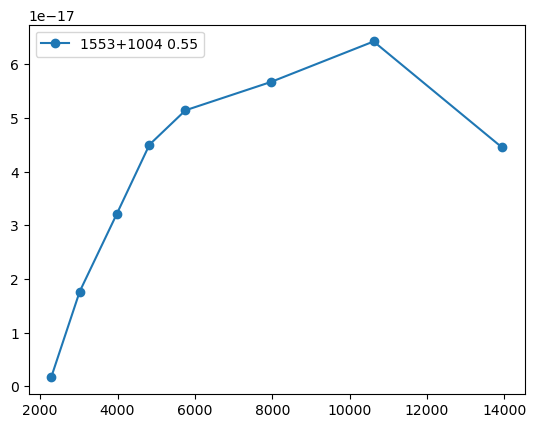

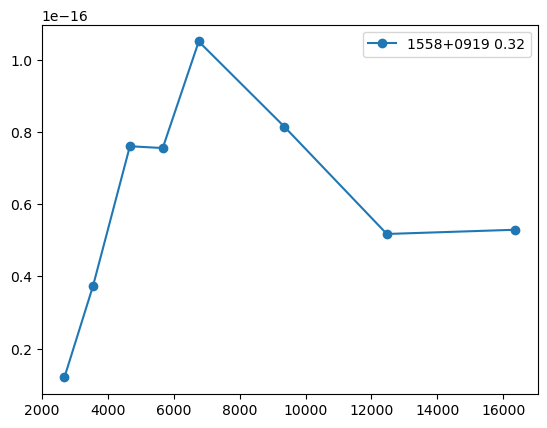

In [5]:
for index, name in enumerate(w2m_names):
    zsp = redshift[index]
    # set up a plot
    plt.figure()
    # plot the original SED
    plt.plot(lam.value/(1+zsp),
             [flam_u.value[index],flam_g.value[index],flam_r.value[index],flam_i.value[index],flam_z.value[index],flam_j.value[index],flam_h.value[index],flam_k.value[index]],
             marker='o', label=name+' {}'.format(round(zsp,5)))
#     plt.xlim(3000/(1+zsp),24500/(1+zsp))
#     plt.ylim(0,0.5e-15)
    plt.legend()    
    
